# Download statistics for machine-learning libraries from Anaconda

This notebook aggregates some package download stats accross anaconda sources.
pypi sources can be inspected online, eg on [clickpy](https://clickpy.clickhouse.com/dashboard/scikit-learn)

Upstream [README](https://github.com/ContinuumIO/anaconda-package-data/blob/master/README.md#quickstart).

The following packages are useful to install to run it: intake, dask, requests, aiohttp, pyarrow, intake-parquet, s3fs, matplotlib

In [ ]:
# Import necessary libraries
import intake
import dask
import pandas as pd

In [2]:
# Get the data
cat = intake.open_catalog('https://raw.githubusercontent.com/anaconda/anaconda-package-data/master/catalog/anaconda_package_data.yaml')

In [3]:
# required variable assignments
years = range(2023, 2026)
packages = ["numpy", "scikit-learn", "pytorch", "cuml"]

#data_source = "anaconda"

In [4]:
# Initialize the dataframe to store the results
downloads = pd.DataFrame({
    "pkg_name": [],
    "year": [],
    "downloads": [
    ]
})

# Download the data for each year and package, and aggregate per year
for year in years:
    print(year)
    df_year_monthly_res = cat.anaconda_package_data_by_year_month_res(year=year).to_dask().compute()
    for pkg_name in packages:
        pkg_year = df_year_monthly_res[
                (df_year_monthly_res["pkg_name"] == pkg_name)
                #& (df_year_monthly_res["data_source"] == data_source)   
            ].reset_index(drop=True)['counts'].sum()
        downloads = pd.concat([downloads, pd.DataFrame({
            "pkg_name": [pkg_name],
            "year": [year],
            "downloads": [pkg_year]
        })], ignore_index=True)

2023
2024
2025


In [23]:
downloads['year'] = downloads['year'].astype(int)
downloads['downloads'] = downloads['downloads'].astype(int)
downloads.to_csv("anaconda_downloads.csv", index=False)
downloads

,pkg_name,year,downloads
0,numpy,2023,46315203
1,scikit-learn,2023,15485322
2,pytorch,2023,11001560
3,cuml,2023,171191
4,numpy,2024,53147898
5,scikit-learn,2024,19750039
6,pytorch,2024,11969746
7,cuml,2024,336401
8,numpy,2025,76046926
9,scikit-learn,2025,23826374


In [17]:
 # Pivot the dataframe to have years as columns and package names as index
pivot_df = downloads.pivot(index='pkg_name', columns='year', values='downloads')
pivot_df

year,2023,2024,2025
pkg_name,,,
cuml,171191,336401,145292
numpy,46315203,53147898,76046926
pytorch,11001560,11969746,11595039
scikit-learn,15485322,19750039,23826374


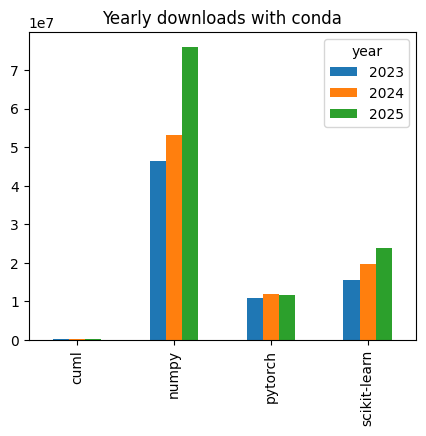

In [24]:
# Use the pivoted dataframe to create a bar plot
pivot_df.plot(kind='bar', figsize=(5, 4), title='Yearly downloads with conda')
from matplotlib import pyplot as plt
plt.xlabel("");

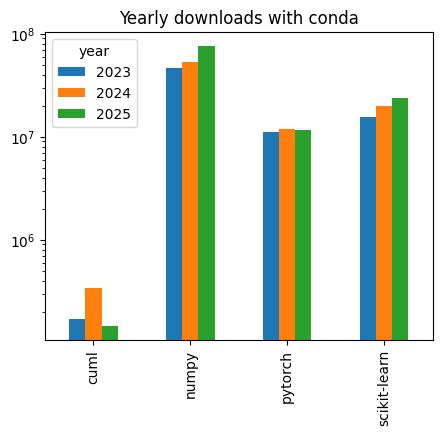

In [25]:
# Same but in log scale, to facilate the comparison of the packages with lower download counts
pivot_df.plot(kind='bar', figsize=(5, 4), title='Yearly downloads with conda')
ax = plt.gca()
ax.set_yscale('log')
plt.xlabel("");

In [27]:
# Let's check which channels we have covered
list(df_year_monthly_res['data_source'].unique())

['conda-forge',
 'rapidsai-nightly',
 'bioconda',
 'nvidia',
 'anaconda',
 'rapidsai',
 'pytorch',
 'pyviz',
 'pytorch-test',
 'plotly',
 'rdkit']